
# Extended Lab: Simple Linear Regression with OLS

**Based on:** *Ordinary Least Squares*, *Linear Model Assumptions*, and
*Model Validation & Regression Variations* notebooks, and Chapter 6 of
*Building Statistical Models in Python*.

This lab extends the original three notebooks into a single, structured,
end-to-end walkthrough. Read `00_Background_Theory.md` first for the
underlying theory. Each part below builds on the last:

1. Part A — OLS from scratch on synthetic data
2. Part B — Coefficients of correlation & determination
3. Part C — The four assumptions, demonstrated with controlled synthetic examples
4. Part D — Fitting and reading a real `statsmodels` OLS summary
5. Part E — Full diagnostic plot suite
6. Part F — Serial correlation: Durbin-Watson, ACF/PACF, differencing
7. Part G — Model validation: train/test split & naive baseline
8. Part H — Extension exercises (not in the source notebooks) to push your understanding further

Run cells top-to-bottom. Markdown "🧠 Think About It" cells pose questions —
answer them in the cell provided before moving on.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import skewnorm
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

sns.set_style("whitegrid")
RNG = np.random.default_rng(2022)


## Part A — OLS From Scratch

We generate synthetic data from a *known* model `y = 2x + 3 + noise`, so we can check whether our estimator recovers the true parameters.

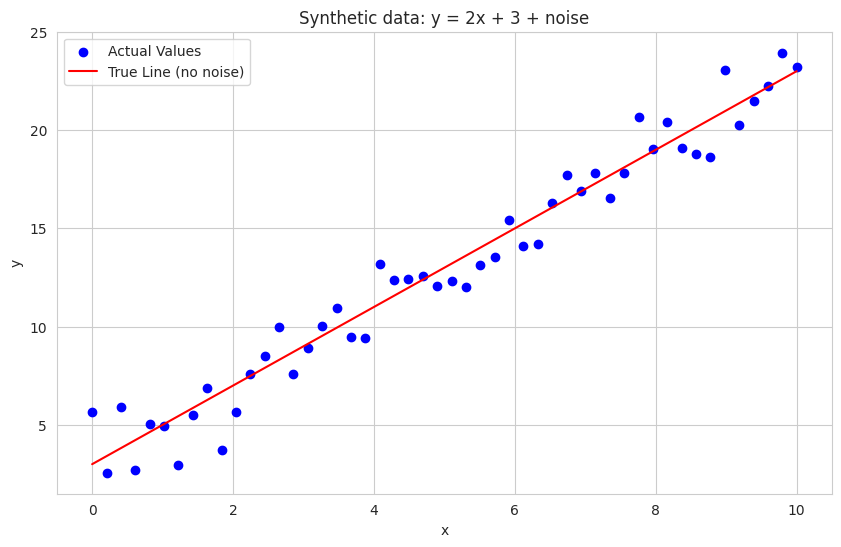

In [2]:
error = RNG.normal(0, 1, 50)
x = np.linspace(0, 10, 50)
y = 2 * x + 3 + error

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', label='Actual Values')
plt.plot(x, 2 * x + 3, color='red', label='True Line (no noise)')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Synthetic data: y = 2x + 3 + noise')
plt.legend()
plt.show()


Implement the closed-form OLS estimator directly from the normal equations:

```
β̂1 = Σ(x_i - x̄)(y_i - ȳ) / Σ(x_i - x̄)²
β̂0 = ȳ - β̂1·x̄
```

In [3]:
def least_squares_method(x, y):
    x_mean = x.mean()
    y_mean = y.mean()
    beta1 = ((x - x_mean) * (y - y_mean)).sum(axis=0) / ((x - x_mean) ** 2).sum(axis=0)
    beta0 = y_mean - (beta1 * x_mean)
    return beta0, beta1

beta0_hat, beta1_hat = least_squares_method(x, y)
print(f"Estimated intercept (beta0_hat): {beta0_hat:.4f}  (true = 3)")
print(f"Estimated slope     (beta1_hat): {beta1_hat:.4f}  (true = 2)")


Estimated intercept (beta0_hat): 2.8451  (true = 3)
Estimated slope     (beta1_hat): 2.0116  (true = 2)


🧠 **Think About It:** Re-run the data-generation cell a few times (or increase `error`'s scale). How much does `beta1_hat` move around? What does this tell you about *sampling variability* of an OLS estimate from a small (n=50) sample?

In [4]:
# Your exploration here


## Part B — Coefficients of Correlation and Determination

We verify by hand that `r²` (coefficient of determination) equals the square
of the Pearson correlation coefficient `r`, and that it matches `statsmodels`'
`R-squared` output.

In [5]:
X = sm.add_constant(x)
model_A = sm.OLS(y, X).fit()

r = np.corrcoef(x, y)[0, 1]
r_squared_manual = r ** 2
ss_res = np.sum((y - model_A.fittedvalues) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r_squared_from_ss = 1 - ss_res / ss_tot

print(f"Pearson r:                 {r:.4f}")
print(f"r^2 (r squared manually):  {r_squared_manual:.4f}")
print(f"r^2 (1 - SSres/SStot):     {r_squared_from_ss:.4f}")
print(f"statsmodels R-squared:     {model_A.rsquared:.4f}")


Pearson r:                 0.9789
r^2 (r squared manually):  0.9583
r^2 (1 - SSres/SStot):     0.9583
statsmodels R-squared:     0.9583


Simulate a few different correlation strengths to build intuition for what different `r` values *look like* in a scatter plot (compare to Figure 6.3-6.5 in the source text).

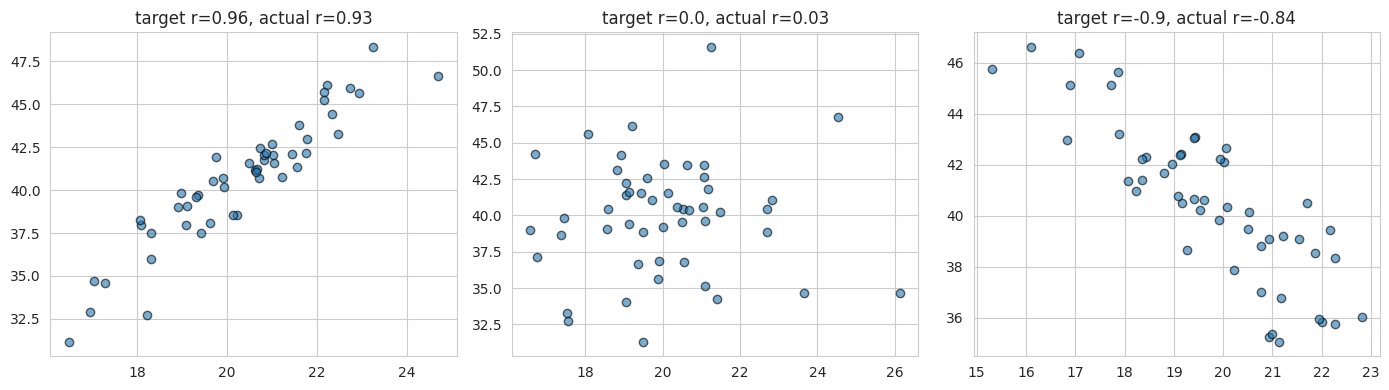

In [6]:
def simulate_correlated(r_target, n=50, rng=RNG):
    mean = [20, 40]
    cov = [[4, 4 * r_target * 2], [4 * r_target * 2, 16]]  # crude construction for illustration
    data = rng.multivariate_normal(mean, cov, size=n)
    return data[:, 0], data[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, r_target in zip(axes, [0.96, 0.0, -0.9]):
    xs, ys = simulate_correlated(r_target)
    r_actual = np.corrcoef(xs, ys)[0, 1]
    ax.scatter(xs, ys, alpha=0.6, edgecolor='k')
    ax.set_title(f"target r={r_target}, actual r={r_actual:.2f}")
fig.tight_layout()
plt.show()


## Part C — The Four Assumptions (Controlled Synthetic Demonstrations)

Because we control the data-generating process here, we know exactly which assumption is violated in each example — useful for calibrating your eye before you look at real, messier data in Part D onward.

### C.1 — Linearity: three different true relationships

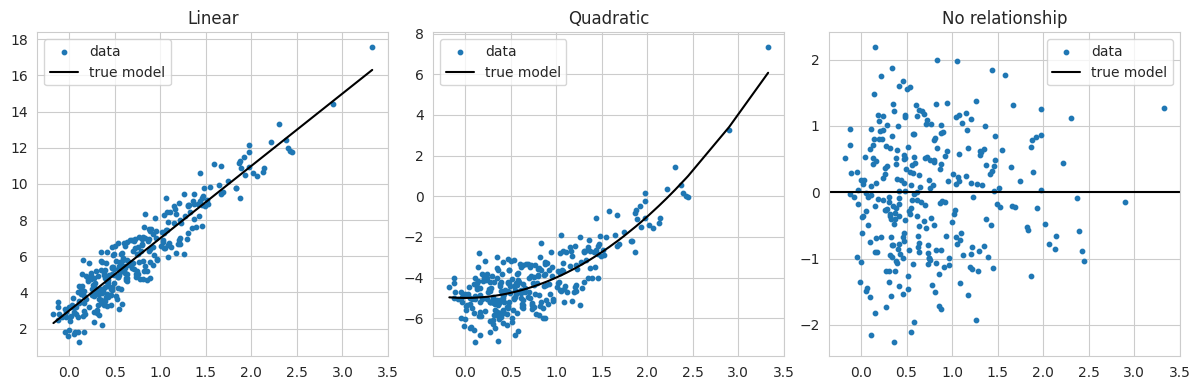

In [7]:
n_points = 300
noise = RNG.normal(size=n_points)
a = 10
x_skew = np.sort(skewnorm.rvs(a, size=n_points))

y_lin = x_skew * 4 + 3 + noise
y_lin_true = x_skew * 4 + 3

y_quad = x_skew ** 2 - 5 + noise
y_quad_true = x_skew ** 2 - 5

y_none = noise  # x and y unrelated

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].scatter(x_skew, y_lin, s=10, label='data'); ax[0].plot(x_skew, y_lin_true, c='k', label='true model'); ax[0].set_title('Linear'); ax[0].legend()
ax[1].scatter(x_skew, y_quad, s=10, label='data'); ax[1].plot(x_skew, y_quad_true, c='k', label='true model'); ax[1].set_title('Quadratic'); ax[1].legend()
ax[2].scatter(x_skew, y_none, s=10, label='data'); ax[2].axhline(0, c='k', label='true model'); ax[2].set_title('No relationship'); ax[2].legend()
fig.tight_layout()
plt.show()


🧠 **Think About It:** A simple linear model is only appropriate for the leftmost panel. What would the Residuals-vs-Fitted plot look like if you (incorrectly) fit a straight line to the quadratic panel? Sketch/predict it before you get to Part E, then come back and check.

### C.2 — Normality of residuals, even when x and y are skewed

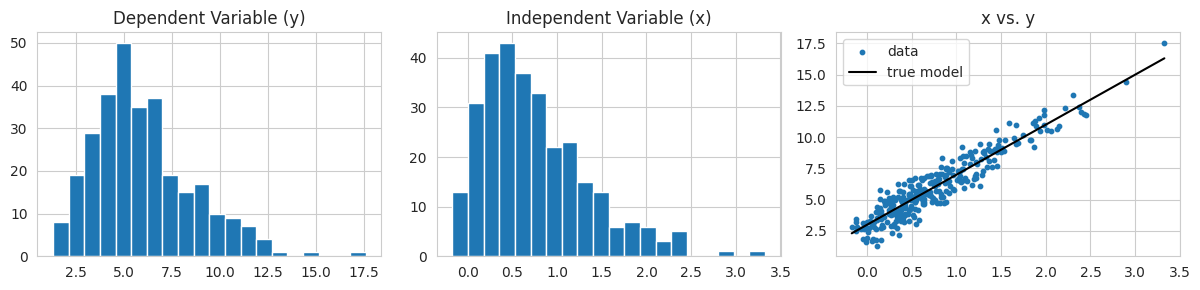

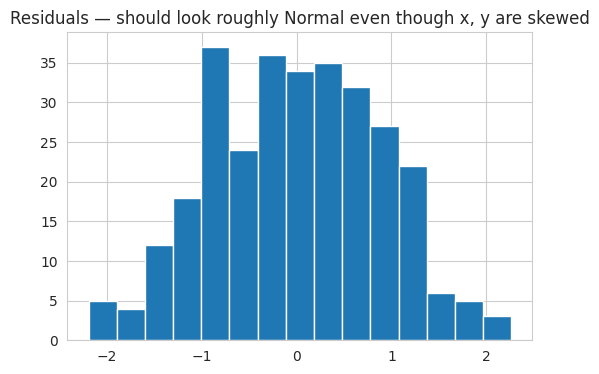

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].hist(y_lin, bins=20); ax[0].set_title("Dependent Variable (y)")
ax[1].hist(x_skew, bins=20); ax[1].set_title("Independent Variable (x)")
ax[2].scatter(x_skew, y_lin, s=10, label='data'); ax[2].plot(x_skew, y_lin_true, c='k', label='true model')
ax[2].set_title("x vs. y"); ax[2].legend()
fig.tight_layout()
plt.show()

X_lin = sm.add_constant(x_skew)
model_lin = sm.OLS(y_lin, X_lin).fit()
residuals_lin = model_lin.resid

plt.figure(figsize=(6, 4))
plt.hist(residuals_lin, bins=15)
plt.title("Residuals — should look roughly Normal even though x, y are skewed")
plt.show()


### C.3 — Homoscedasticity vs. two ways it can break: an outlier, and growing variance

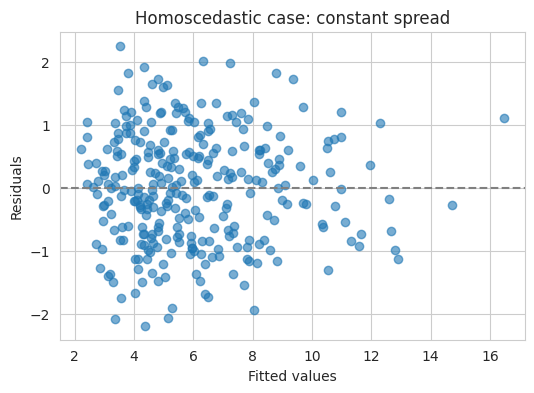

In [9]:
pred_lin = model_lin.predict(X_lin)
plt.figure(figsize=(6, 4))
plt.scatter(pred_lin, residuals_lin, alpha=0.6)
plt.axhline(0, color='grey', linestyle='--')
plt.xlabel("Fitted values"); plt.ylabel("Residuals")
plt.title("Homoscedastic case: constant spread")
plt.show()


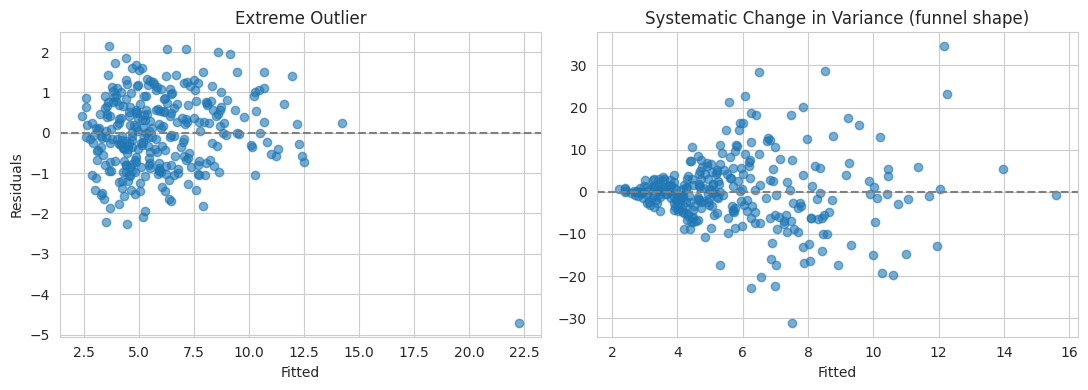

In [10]:
# Break #1: a single extreme outlier
x_with_outlier = x_skew.copy()
x_with_outlier[-1] = 5
X_out = sm.add_constant(x_with_outlier)
model_out = sm.OLS(y_lin, X_out).fit()
pred_out = model_out.predict(X_out)
resid_out = model_out.resid

# Break #2: variance that grows with x (proportional noise)
prop_noise = np.array([RNG.normal(0, i / 20, size=1)[0] for i in range(x_skew.size)])
y_growing = y_lin + prop_noise
X_grow = sm.add_constant(x_skew)
model_grow = sm.OLS(y_growing, X_grow).fit()
pred_grow = model_grow.predict(X_grow)
resid_grow = model_grow.resid

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(pred_out, resid_out, alpha=0.6); ax[0].axhline(0, color='grey', linestyle='--')
ax[0].set_title("Extreme Outlier"); ax[0].set_xlabel("Fitted"); ax[0].set_ylabel("Residuals")
ax[1].scatter(pred_grow, resid_grow, alpha=0.6); ax[1].axhline(0, color='grey', linestyle='--')
ax[1].set_title("Systematic Change in Variance (funnel shape)"); ax[1].set_xlabel("Fitted")
fig.tight_layout()
plt.show()


🧠 **Think About It:** In the outlier panel, most residuals still look fine — it's one point ruining the picture. In the funnel panel, the *whole pattern* is compromised. Why might these two problems call for different fixes (e.g., investigate-and-maybe-drop vs. transform-the-target)?

### C.4 — Independence: there's no diagnostic plot for this one

Unlike linearity, normality, and homoscedasticity, independence is a property of *how the data were collected*, not something you can read off a residual scatter plot in general. The closest we get is checking for **serial correlation** when data are ordered (e.g., by time) — covered in Part F.

## Part D — Real Data: `statsmodels` macrodata

We now move to real economic time series: does real gross private domestic investment (`realinv`) help explain real private disposable income (`realdpi`)?

In [11]:
df = sm.datasets.macrodata.load().data
df = sm.add_constant(df, prepend=False)
df_mod = df[['realinv', 'realdpi', 'const']].copy()
df_mod.head()


,realinv,realdpi,const
0,286.898,1886.9,1.0
1,310.859,1919.7,1.0
2,289.226,1916.4,1.0
3,299.356,1931.3,1.0
4,331.722,1955.5,1.0


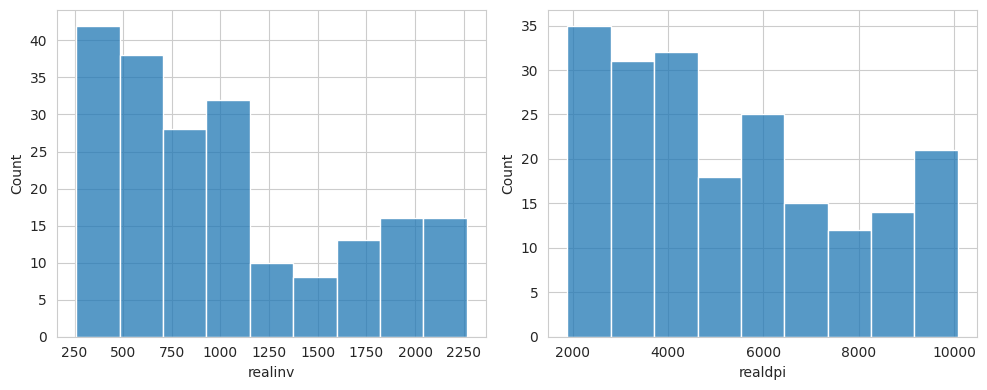

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df_mod['realinv'], ax=ax[0])
sns.histplot(df_mod['realdpi'], ax=ax[1])
fig.tight_layout()
plt.show()


Note: neither variable is normally distributed. That's fine — recall from Part C.2 that OLS only needs the **residuals** to be roughly normal, not the raw inputs.

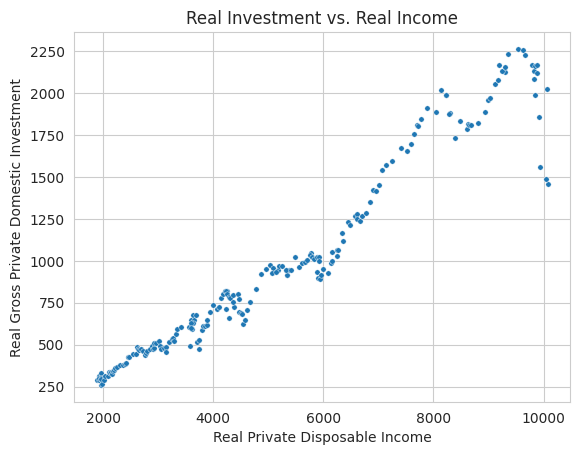

In [13]:
fig = sns.scatterplot(x=df_mod['realdpi'], y=df_mod['realinv'], s=15)
fig.set(xlabel="Real Private Disposable Income", ylabel="Real Gross Private Domestic Investment",
        title="Real Investment vs. Real Income")
plt.show()


In [14]:
ols_model = sm.OLS(df_mod['realdpi'], df_mod[['const', 'realinv']])
compiled_model = ols_model.fit()
print(compiled_model.summary())


                            OLS Regression Results                            
Dep. Variable:                realdpi   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     3384.
Date:                Wed, 26 Aug 2026   Prob (F-statistic):          1.01e-127
Time:                        20:41:14   Log-Likelihood:                -1577.1
No. Observations:                 203   AIC:                             3158.
Df Residuals:                     201   BIC:                             3165.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1234.5164     80.866     15.266      0.0

🧠 **Think About It:** Answer these using the summary table above:
1. Is `realinv` a statistically significant predictor of `realdpi`? How do you know?
2. What proportion of the variance in `realdpi` is explained by `realinv`?
3. What does the Durbin-Watson statistic suggest, and why might that matter given this is *time-ordered* macroeconomic data?

In [15]:
# Your written answers here (as a comment or markdown, your choice)


## Part E — Full Diagnostic Plot Suite

The four-panel diagnostic grid used throughout applied regression work.

/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


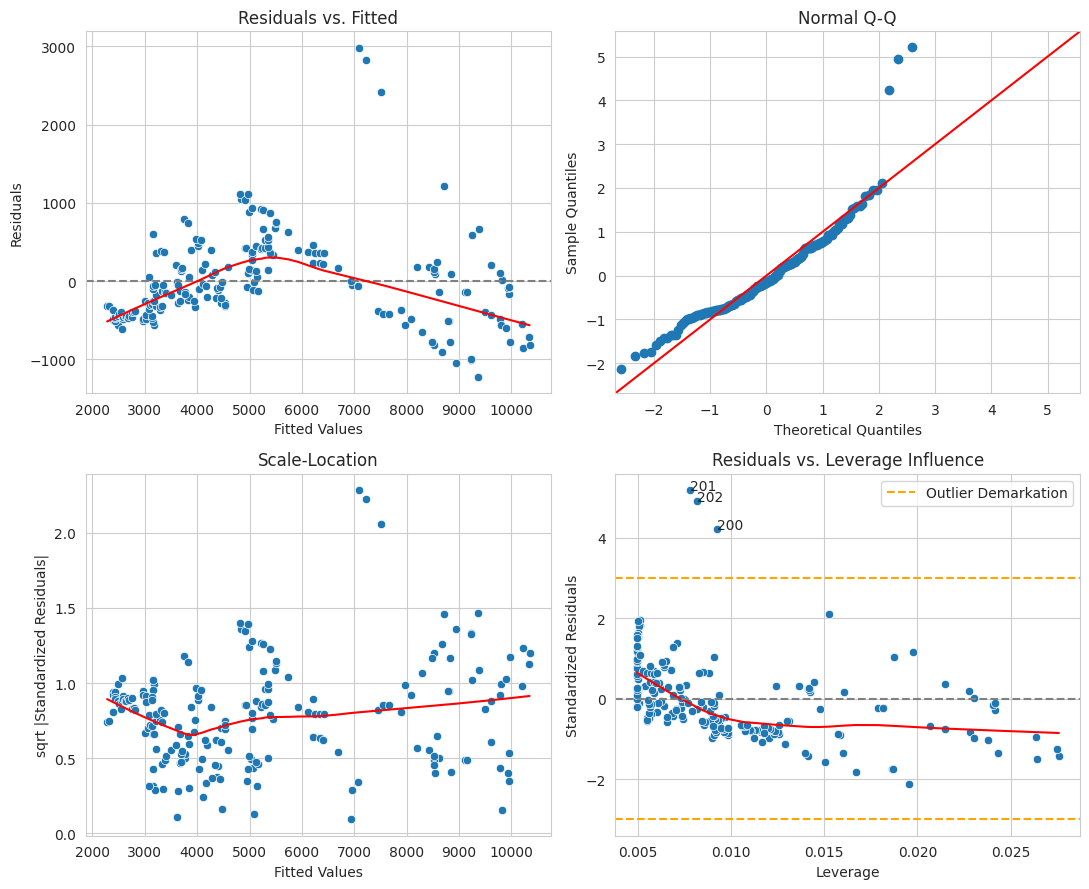

In [16]:
model_residuals = compiled_model.resid
fitted_value = compiled_model.fittedvalues
standardized_residuals = compiled_model.resid_pearson
sqrt_standardized_residuals = np.sqrt(np.abs(compiled_model.get_influence().resid_studentized_internal))
influence = compiled_model.get_influence()
leverage = influence.hat_matrix_diag
cooks_distance = compiled_model.get_influence().cooks_distance[0]

fig, ax = plt.subplots(2, 2, figsize=(11, 9))

# Residuals vs. Fitted
ax[0, 0].set_xlabel('Fitted Values'); ax[0, 0].set_ylabel('Residuals'); ax[0, 0].set_title('Residuals vs. Fitted')
lw1 = lowess(model_residuals, fitted_value)
sns.scatterplot(x=fitted_value, y=model_residuals, ax=ax[0, 0])
ax[0, 0].axhline(y=0, color='grey', linestyle='--')
ax[0, 0].plot(lw1[:, 0], lw1[:, 1], color='red')

# Normal Q-Q
ax[0, 1].set_title('Normal Q-Q')
sm.qqplot(model_residuals, fit=True, line='45', ax=ax[0, 1], c='blue')

# Scale-Location
ax[1, 0].set_xlabel('Fitted Values'); ax[1, 0].set_ylabel('sqrt |Standardized Residuals|'); ax[1, 0].set_title('Scale-Location')
lw2 = lowess(sqrt_standardized_residuals, fitted_value)
sns.scatterplot(x=fitted_value, y=sqrt_standardized_residuals, ax=ax[1, 0])
ax[1, 0].plot(lw2[:, 0], lw2[:, 1], color='red')

# Residuals vs. Leverage
ax[1, 1].set_xlabel('Leverage'); ax[1, 1].set_ylabel('Standardized Residuals'); ax[1, 1].set_title('Residuals vs. Leverage Influence')
lw3 = lowess(standardized_residuals, leverage)
sns.scatterplot(x=leverage, y=standardized_residuals, ax=ax[1, 1])
ax[1, 1].plot(lw3[:, 0], lw3[:, 1], color='red')
ax[1, 1].axhline(y=0, color='grey', linestyle='--')
ax[1, 1].axhline(3, color='orange', linestyle='--', label='Outlier Demarkation')
ax[1, 1].axhline(-3, color='orange', linestyle='--')
ax[1, 1].legend(loc='upper right')

leverages_flagged = []
for i in range(len(cooks_distance)):
    if cooks_distance[i] > 0.5:
        leverages_flagged.append(leverage[i])
        ax[1, 1].annotate(f"{i} Cook's D > 0.5", xy=(leverage[i], standardized_residuals[i]))
if leverages_flagged:
    ax[1, 1].axvline(min(leverages_flagged), color='red', linestyle='--', label="Cook's Distance")
for i in range(len(standardized_residuals)):
    if standardized_residuals[i] > 3 or standardized_residuals[i] < -3:
        ax[1, 1].annotate(i, xy=(leverage[i], standardized_residuals[i]))

fig.tight_layout()
plt.show()


🧠 **Think About It:** Using the four panels above, write one sentence per plot describing what it tells you about this specific model (not the theory in general — the actual shape you see here).

## Part F — Serial Correlation: Durbin-Watson, ACF/PACF, Differencing

The Durbin-Watson statistic in the summary table (~0.095 for this model) flags
strong positive autocorrelation. Let's investigate with ACF/PACF and try
first-order differencing as a remedy.

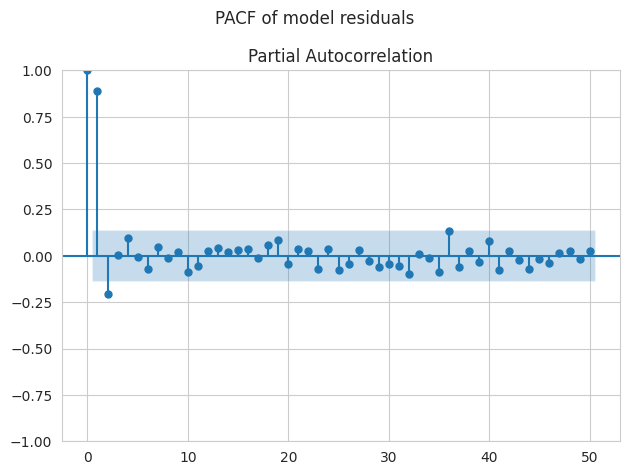

In [17]:
fig = plot_pacf(compiled_model.resid, alpha=0.05, lags=50)
fig.suptitle("PACF of model residuals")
fig.tight_layout()
plt.show()


The PACF above should show strong, significant correlation at lag 1 — this is the signature of the positive autocorrelation the Durbin-Watson statistic already flagged.

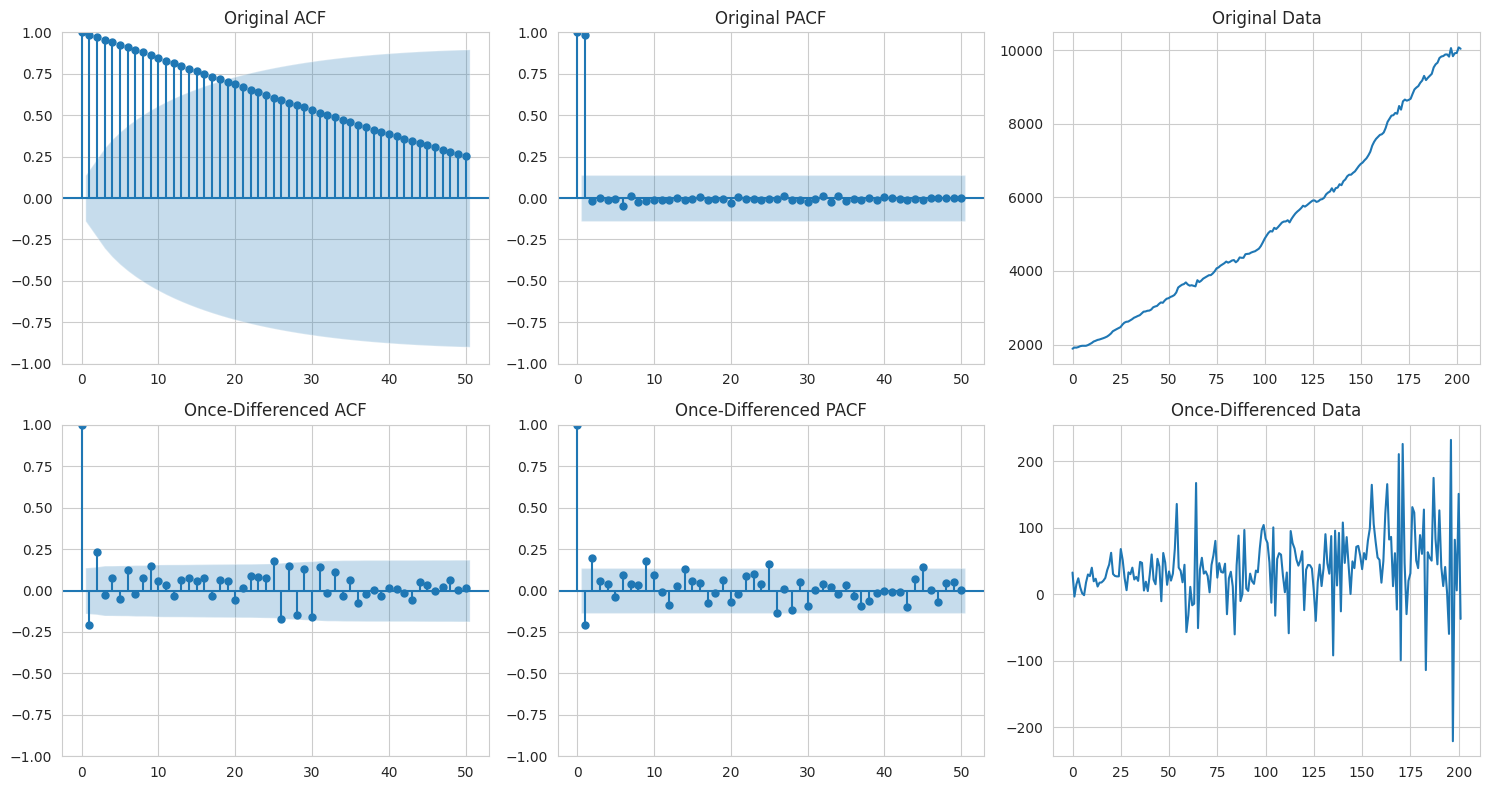

In [18]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
plot_acf(df_mod['realdpi'], alpha=0.05, lags=50, ax=ax[0, 0]); ax[0, 0].set_title('Original ACF')
plot_pacf(df_mod['realdpi'], alpha=0.05, lags=50, ax=ax[0, 1]); ax[0, 1].set_title('Original PACF')
ax[0, 2].set_title('Original Data'); ax[0, 2].plot(df_mod['realdpi'])

plot_acf(np.diff(df_mod['realdpi'], n=1), alpha=0.05, lags=50, ax=ax[1, 0]); ax[1, 0].set_title('Once-Differenced ACF')
plot_pacf(np.diff(df_mod['realdpi'], n=1), alpha=0.05, lags=50, ax=ax[1, 1]); ax[1, 1].set_title('Once-Differenced PACF')
ax[1, 2].set_title('Once-Differenced Data'); ax[1, 2].plot(np.diff(df_mod['realdpi'], n=1))

fig.tight_layout()
plt.show()


In [19]:
# Re-fit on the differenced series (drop one row from const to match length)
ols_model_1diff = sm.OLS(
    np.diff(df_mod['realdpi'], n=1),
    pd.concat([df_mod['const'].iloc[:-1], pd.Series(np.diff(df_mod['realinv'], n=1))], axis=1)
)
compiled_model_1diff = ols_model_1diff.fit()
print(compiled_model_1diff.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     9.437
Date:                Wed, 26 Aug 2026   Prob (F-statistic):            0.00242
Time:                        20:41:15   Log-Likelihood:                -1085.6
No. Observations:                 202   AIC:                             2175.
Df Residuals:                     200   BIC:                             2182.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.8531      3.724     10.433      0.0

🧠 **Think About It:**
1. Compare `R-squared` between the levels model (Part D) and the differenced model. Why did it drop so much?
2. Compare the Durbin-Watson statistic before and after differencing. Using the critical-value logic from the background reading (bounds ≈ [1.758, 1.779] for n≈200, k=1, and [2.221, 2.242] for the negative-autocorrelation check), what do you conclude about the differenced model's residuals?
3. The chapter argues that a dedicated time-series model would still be preferable here. Why might that be, even after differencing reduces the autocorrelation?

## Part G — Model Validation: Train/Test Split & Naive Baseline

We go back to the **levels** model (`realdpi ~ realinv`) from Part D and validate it two ways: (1) train vs. test coefficient/metric stability, and (2) beating a naive "always predict the mean" baseline.

In [20]:
train, test = train_test_split(df_mod, train_size=0.75, shuffle=True, random_state=42)

ols_model_train = sm.OLS(train['realdpi'], train[['const', 'realinv']])
compiled_model_train = ols_model_train.fit()
print(compiled_model_train.summary())


                            OLS Regression Results                            
Dep. Variable:                realdpi   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     2752.
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           2.11e-98
Time:                        20:41:15   Log-Likelihood:                -1176.4
No. Observations:                 152   AIC:                             2357.
Df Residuals:                     150   BIC:                             2363.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1176.6560     91.027     12.927      0.0

In [21]:
ols_model_test = sm.OLS(test['realdpi'], test[['const', 'realinv']])
compiled_model_test = ols_model_test.fit()
print(compiled_model_test.summary())


                            OLS Regression Results                            
Dep. Variable:                realdpi   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     666.9
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           3.43e-30
Time:                        20:41:15   Log-Likelihood:                -399.51
No. Observations:                  51   AIC:                             803.0
Df Residuals:                      49   BIC:                             806.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1405.7460    173.982      8.080      0.0

🧠 **Think About It:** Are the `realinv` coefficient and R-squared similar between the train-only and test-only fits? If they diverged a lot, what would that suggest about the model?

In [22]:
mae_train = mean_absolute_error(train['realdpi'], compiled_model_train.predict(train[['const', 'realinv']]))
naive_mae_train = np.mean(np.abs(train['realdpi'] - train['realdpi'].mean()))

mae_holdout = mean_absolute_error(test['realdpi'], compiled_model_train.predict(test[['const', 'realinv']]))
naive_mae_test = np.mean(np.abs(test['realdpi'] - test['realdpi'].mean()))

print(f"Train MAE (model):        {mae_train:10.2f}")
print(f"Train MAE (naive mean):   {naive_mae_train:10.2f}")
print(f"Holdout MAE (model):      {mae_holdout:10.2f}")
print(f"Holdout MAE (naive mean): {naive_mae_test:10.2f}")


Train MAE (model):            394.42
Train MAE (naive mean):      2068.82
Holdout MAE (model):          476.85
Holdout MAE (naive mean):    1999.33


The trained model should beat the naive baseline by a wide margin on both train and holdout data, and the holdout MAE should be roughly comparable to the train MAE (no dramatic overfitting).

## Part H — Extension Exercises

These go beyond what's in the source notebooks — attempt them to deepen your
understanding. Solutions are provided in the companion **Solutions**
notebook, but try first!

1. **Simulation study.** Write a loop that generates 500 synthetic datasets
   from `y = 2x + 3 + N(0, σ)` with `n = 30`, fits OLS each time, and stores
   `beta1_hat`. Plot a histogram of the 500 estimates. How does the spread
   change as you increase `σ` or `n`? (This is an empirical demonstration of
   the sampling distribution of an OLS estimator.)
2. **Heteroscedasticity-robust standard errors.** Refit the macrodata model
   using `compiled_model = ols_model.fit(cov_type='HC3')`. Compare the
   standard errors and p-values to the default (`nonrobust`) fit. Does the
   significance conclusion change?
3. **Alternative predictor.** Try predicting `realdpi` from a different
   column in `sm.datasets.macrodata.load().data` (e.g., `realgdp`). Run the
   same assumption checks — does this predictor look "better behaved" than
   `realinv`?
4. **Outlier sensitivity.** Take the Part C.3 outlier example
   (`x_with_outlier`) and refit the model with and without the outlier
   point. How much does `beta1_hat` change? Relate this back to the Cook's
   distance concept from Part E.
5. **From formula to code, one more time.** Without looking back at the
   `least_squares_method` function, re-derive and re-implement it from the
   normal equations in the background reading. Confirm it agrees with
   `statsmodels` to several decimal places.
